Our goal is to simplify the Lagrange equations of the first kind for our system, obtaining numerically solvable ODEs in the process.

In [1]:
#variables and functions
t, R, M, m, alpha, g, B1, B2, B3, A1, A2 = var('t R M m alpha g B1 B2 B3 A1 A2') 
#t is time, R is radius, M is mass, m is total magnetic moment, alpha is slope, g is gravitational acceleration, B are magnetic field comps, A are integration constants
x = function('x')(t)
y = function('y')(t)
phi = function('phi')(t)
psi = function('psi')(t)
theta = function('theta')(t)
#we need some symbolic derivatives
phidd, psidd, thetadd = var('phidd psidd thetadd')
#lagrange equations as labled in my sheet
A = diff(x,t) == R*(phi.diff()*sin(theta)*cos(psi)+alpha*phi.diff()*cos(theta)-theta.diff()*sin(psi)+alpha*psi.diff())
dA = diff(x,t,2) == diff(A.rhs(),t,1) #differentiate only once as A already contains the first derivative of x

B = diff(y,t) == R*(phi.diff()*sin(theta)*sin(psi)+theta.diff()*cos(psi))
dB = diff(y,t,2) == diff(B.rhs(),t,1)

C = 0 == (5*R^2*M*(phi.diff(2)+psi.diff(2)*cos(theta)-psi.diff()*theta.diff()*sin(theta)) -m*(B1*cos(phi)*sin(theta)+B2*sin(phi)*sin(theta))+M*R*x.diff(2)*(sin(theta)*cos(psi)+alpha*cos(theta))  
- (M*R*x.diff()+A1)*(psi.diff()*sin(theta)*sin(psi)+alpha*theta.diff()*sin(theta)-theta.diff()*cos(theta)*cos(psi)) + (R*m*(1-alpha^2)*y.diff()-R*M*g*alpha*t+A2)*(theta.diff()*cos(theta)*sin(psi)+psi.diff()*sin(theta)*cos(psi))
    -R*M*(g*alpha-y.diff(2)*(1+alpha^2)) * sin(theta)*sin(psi))
C = C.subs({ x.diff(): A.rhs(), y.diff():B.rhs(), x.diff(2):dA.rhs(), y.diff(2):dB.rhs() })
C.full_simplify()
D = 0 == (5*R^2*M*theta.diff(2) + m * (-B1*sin(phi)*cos(theta)+B2*cos(phi)*cos(theta)+B3*sin(theta)) - ( M * R * x.diff() + A1 ) * ( phi.diff() * cos(theta) * cos(psi) - alpha * phi.diff()*sin(theta) + psi.diff() * cos(psi))
    - M*R*x.diff(2)*sin(psi) - (-R*M*(1+alpha^2)*y.diff()+R*M*g*alpha*t+A2)*sin(psi)*(phi.diff()*cos(theta)*sin(psi)-1)-R*M*(g*alpha - y.diff(2)*(1+alpha^2))*cos(psi) )
D = D.subs({ x.diff(): A.rhs(), y.diff():B.rhs(), x.diff(2):dA.rhs(), y.diff(2):dB.rhs() })
D.full_simplify()
E = 0 == (5*R^2*M*(psi.diff(2)+phi.diff(2)*cos(theta)-theta.diff()*phi.diff()*sin(theta)) - (M*R*x.diff() + A1) * (phi.diff() * sin(theta)*sin(psi)+theta.diff()*cos(psi))
         - alpha*M*R*x.diff(2)+(-R*M*(1+alpha^2)*y.diff()+R*M*g*alpha*t+A2) * (theta.diff()*sin(psi)-phi.diff()*sin(theta)*cos(psi)) )
E = E.subs({ x.diff(): A.rhs(), y.diff():B.rhs(), x.diff(2):dA.rhs(), y.diff(2):dB.rhs() })
E.full_simplify()
show(A)
show(dA)
show(B)
show(dB)
show(C)
show(D)
show(E)

diff(x(t), t) == (alpha*cos(theta(t))*diff(phi(t), t) + cos(psi(t))*sin(theta(t))*diff(phi(t), t) + alpha*diff(psi(t), t) - sin(psi(t))*diff(theta(t), t))*R

diff(x(t), t, t) == -(sin(psi(t))*sin(theta(t))*diff(phi(t), t)*diff(psi(t), t) - cos(psi(t))*cos(theta(t))*diff(phi(t), t)*diff(theta(t), t) + alpha*sin(theta(t))*diff(phi(t), t)*diff(theta(t), t) - alpha*cos(theta(t))*diff(phi(t), t, t) - cos(psi(t))*sin(theta(t))*diff(phi(t), t, t) + cos(psi(t))*diff(psi(t), t)*diff(theta(t), t) - alpha*diff(psi(t), t, t) + sin(psi(t))*diff(theta(t), t, t))*R

diff(y(t), t) == (sin(psi(t))*sin(theta(t))*diff(phi(t), t) + cos(psi(t))*diff(theta(t), t))*R

diff(y(t), t, t) == (cos(psi(t))*sin(theta(t))*diff(phi(t), t)*diff(psi(t), t) + cos(theta(t))*sin(psi(t))*diff(phi(t), t)*diff(theta(t), t) + sin(psi(t))*sin(theta(t))*diff(phi(t), t, t) - sin(psi(t))*diff(psi(t), t)*diff(theta(t), t) + cos(psi(t))*diff(theta(t), t, t))*R

0 == -(sin(psi(t))*sin(theta(t))*diff(phi(t), t)*diff(psi(t), t) - cos(psi(t))*cos(theta(t))*diff(phi(t), t)*diff(theta(t), t) + alpha*sin(theta(t))*diff(phi(t), t)*diff(theta(t), t) - alpha*cos(theta(t))*diff(phi(t), t, t) - cos(psi(t))*sin(theta(t))*diff(phi(t), t, t) + cos(psi(t))*diff(psi(t), t)*diff(theta(t), t) - alpha*diff(psi(t), t, t) + sin(psi(t))*diff(theta(t), t, t))*(alpha*cos(theta(t)) + cos(psi(t))*sin(theta(t)))*M*R^2 + ((cos(psi(t))*sin(theta(t))*diff(phi(t), t)*diff(psi(t), t) + cos(theta(t))*sin(psi(t))*diff(phi(t), t)*diff(theta(t), t) + sin(psi(t))*sin(theta(t))*diff(phi(t), t, t) - sin(psi(t))*diff(psi(t), t)*diff(theta(t), t) + cos(psi(t))*diff(theta(t), t, t))*(alpha^2 + 1)*R - alpha*g)*M*R*sin(psi(t))*sin(theta(t)) - 5*(sin(theta(t))*diff(psi(t), t)*diff(theta(t), t) - cos(theta(t))*diff(psi(t), t, t) - diff(phi(t), t, t))*M*R^2 - ((sin(psi(t))*sin(theta(t))*diff(phi(t), t) + cos(psi(t))*diff(theta(t), t))*(alpha^2 - 1)*R^2*m + M*R*alpha*g*t - A2)*(cos(psi(t))*sin(theta(t))*diff(psi(t), t) + cos(theta(t))*sin(psi(t))*diff(theta(t), t)) - ((alpha*cos(theta(t))*diff(phi(t), t) + cos(psi(t))*sin(theta(t))*diff(phi(t), t) + alpha*diff(psi(t), t) - sin(psi(t))*diff(theta(t), t))*M*R^2 + A1)*(sin(psi(t))*sin(theta(t))*diff(psi(t), t) - cos(psi(t))*cos(theta(t))*diff(theta(t), t) + alpha*sin(theta(t))*diff(theta(t), t)) - (B1*cos(phi(t))*sin(theta(t)) + B2*sin(phi(t))*sin(theta(t)))*m

0 == (sin(psi(t))*sin(theta(t))*diff(phi(t), t)*diff(psi(t), t) - cos(psi(t))*cos(theta(t))*diff(phi(t), t)*diff(theta(t), t) + alpha*sin(theta(t))*diff(phi(t), t)*diff(theta(t), t) - alpha*cos(theta(t))*diff(phi(t), t, t) - cos(psi(t))*sin(theta(t))*diff(phi(t), t, t) + cos(psi(t))*diff(psi(t), t)*diff(theta(t), t) - alpha*diff(psi(t), t, t) + sin(psi(t))*diff(theta(t), t, t))*M*R^2*sin(psi(t)) + ((cos(psi(t))*sin(theta(t))*diff(phi(t), t)*diff(psi(t), t) + cos(theta(t))*sin(psi(t))*diff(phi(t), t)*diff(theta(t), t) + sin(psi(t))*sin(theta(t))*diff(phi(t), t, t) - sin(psi(t))*diff(psi(t), t)*diff(theta(t), t) + cos(psi(t))*diff(theta(t), t, t))*(alpha^2 + 1)*R - alpha*g)*M*R*cos(psi(t)) + 5*M*R^2*diff(theta(t), t, t) + ((sin(psi(t))*sin(theta(t))*diff(phi(t), t) + cos(psi(t))*diff(theta(t), t))*(alpha^2 + 1)*M*R^2 - M*R*alpha*g*t - A2)*(cos(theta(t))*sin(psi(t))*diff(phi(t), t) - 1)*sin(psi(t)) - ((alpha*cos(theta(t))*diff(phi(t), t) + cos(psi(t))*sin(theta(t))*diff(phi(t), t) + alpha*diff(psi(t), t) - sin(psi(t))*diff(theta(t), t))*M*R^2 + A1)*(cos(psi(t))*cos(theta(t))*diff(phi(t), t) - alpha*sin(theta(t))*diff(phi(t), t) + cos(psi(t))*diff(psi(t), t)) + (B2*cos(phi(t))*cos(theta(t)) - B1*cos(theta(t))*sin(phi(t)) + B3*sin(theta(t)))*m

0 == (sin(psi(t))*sin(theta(t))*diff(phi(t), t)*diff(psi(t), t) - cos(psi(t))*cos(theta(t))*diff(phi(t), t)*diff(theta(t), t) + alpha*sin(theta(t))*diff(phi(t), t)*diff(theta(t), t) - alpha*cos(theta(t))*diff(phi(t), t, t) - cos(psi(t))*sin(theta(t))*diff(phi(t), t, t) + cos(psi(t))*diff(psi(t), t)*diff(theta(t), t) - alpha*diff(psi(t), t, t) + sin(psi(t))*diff(theta(t), t, t))*M*R^2*alpha - 5*(sin(theta(t))*diff(phi(t), t)*diff(theta(t), t) - cos(theta(t))*diff(phi(t), t, t) - diff(psi(t), t, t))*M*R^2 + ((sin(psi(t))*sin(theta(t))*diff(phi(t), t) + cos(psi(t))*diff(theta(t), t))*(alpha^2 + 1)*M*R^2 - M*R*alpha*g*t - A2)*(cos(psi(t))*sin(theta(t))*diff(phi(t), t) - sin(psi(t))*diff(theta(t), t)) - ((alpha*cos(theta(t))*diff(phi(t), t) + cos(psi(t))*sin(theta(t))*diff(phi(t), t) + alpha*diff(psi(t), t) - sin(psi(t))*diff(theta(t), t))*M*R^2 + A1)*(sin(psi(t))*sin(theta(t))*diff(phi(t), t) + cos(psi(t))*diff(theta(t), t))

Now we try a numerical approach. First, we need explicit forms for the three remaining coupled ODEs C-E to use the built-in ODE solver.

In [2]:
C = C.subs({ phi.diff(2):phidd, psi.diff(2):psidd, theta.diff(2):thetadd })
D = D.subs({ phi.diff(2):phidd, psi.diff(2):psidd, theta.diff(2):thetadd })
E = E.subs({ phi.diff(2):phidd, psi.diff(2):psidd, theta.diff(2):thetadd })
sol = solve([C, D, E], [phidd, psidd, thetadd], solution_dict=True)
phi_explicit   = sol[0][phidd]
psi_explicit   = sol[0][psidd]
theta_explicit = sol[0][thetadd]

The ODE solver needs symbolic expressions, so we replace everything accordingly.

In [221]:
X, Vx, Y, Vy, Phi, Vphi, Psi, Vpsi, Theta, Vtheta = var('X Vx Y Vy Phi Vphi Psi Vpsi Theta Vtheta')
state_vector = {x:X, x.diff():Vx, y:Y, y.diff():Vy, phi:Phi, phi.diff():Vphi, psi:Psi, psi.diff():Vpsi, theta:Theta, theta.diff():Vtheta}
acc_vector = {phi.diff(2):phi_explicit, psi.diff(2):psi_explicit, theta.diff(2):theta_explicit}
phi_dd = phi_explicit.subs(state_vector)
psi_dd = psi_explicit.subs(state_vector)
theta_dd = theta_explicit.subs(state_vector)
x_d = A.rhs().subs(state_vector)
x_dd = dA.rhs().subs(acc_vector).subs(state_vector)
y_d = B.rhs().subs(state_vector)
y_dd = dB.rhs().subs(acc_vector).subs(state_vector)

Now, we have a system of 10 coupled ODEs which we want to solve numerically.

In [288]:
f = [x_d, x_dd, y_d, y_dd, Vphi, phi_dd, Vpsi, psi_dd, Vtheta, theta_dd]
#parameters
from scipy.constants import mu_0
B_residual = 12 * 10^3 * 10^(-4) #Residual Flux Density in Tesla (conversion Gauss * 10^-4 = Tesla)
dipole = (4 / 3) * pi * (0.1)^3 * B_residual / mu_0 #is that correct? The value is several orders of magnitude higher than a typical MRI magnet; for now, I go with an empirical value
parameters = { R:0.01, M:0.1, m:0.0, alpha:-1, g:9.81, B1:0.0, B2:0.0, B3:0.0, A1:0.0, A2:0.0 }
#inital values; note that the initial angles are technically also parameters as they determine the direction of m at t=0
X0, Vx0 = 0.1, 5
Y0, Vy0 = 0.0, 0.5
Phi0, Vphi0 = 0.0, 0.0
Psi0, Vpsi0 = 0.0, 0.1
Theta0, Vtheta0 = 0.0, 0.0
initials = [X0, Vx0, Y0, Vy0, Phi0, Vphi0, Psi0, Vpsi0, Theta0, Vtheta0]
#solving
f_num = [expr.subs(parameters) for expr in f]
state_order = [X, Vx, Y, Vy, Phi, Vphi, Psi, Vpsi, Theta, Vtheta]
t0 = 0.0
t1 = 1
dt = .000001
time = srange(t0, t1, dt)
solode = desolve_odeint(f_num, initials, time, state_order)
print("finished")

finished


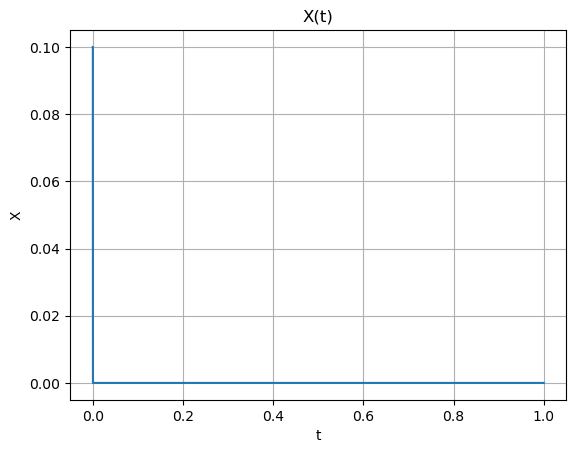

OverflowError: Exceeded cell block limit in Agg.  Please set the value of rcParams['agg.path.chunksize'], (currently 0) to be greater than 100 or increase the path simplification threshold(rcParams['path.simplify_threshold'] = 0.111111111111 by default and path.simplify_threshold = 0.111111111111 on the input).

<Figure size 640x480 with 1 Axes>

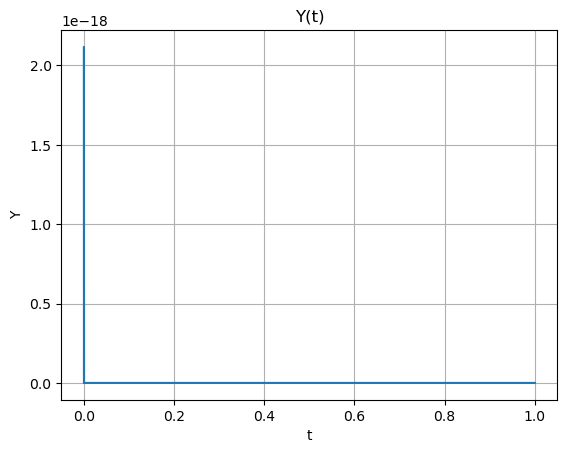

OverflowError: Exceeded cell block limit in Agg.  Please set the value of rcParams['agg.path.chunksize'], (currently 0) to be greater than 100 or increase the path simplification threshold(rcParams['path.simplify_threshold'] = 0.111111111111 by default and path.simplify_threshold = 0.111111111111 on the input).

<Figure size 640x480 with 1 Axes>

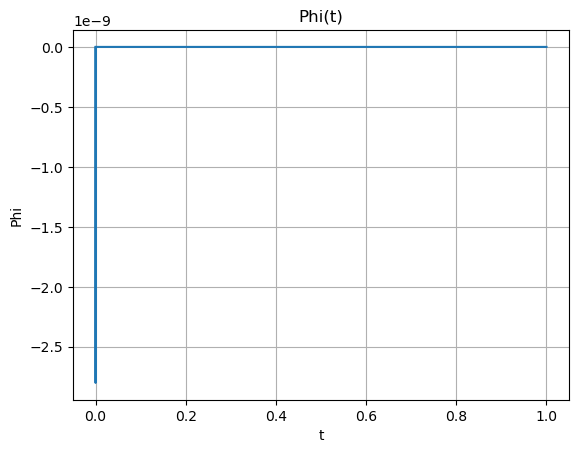

OverflowError: Exceeded cell block limit in Agg.  Please set the value of rcParams['agg.path.chunksize'], (currently 0) to be greater than 100 or increase the path simplification threshold(rcParams['path.simplify_threshold'] = 0.111111111111 by default and path.simplify_threshold = 0.111111111111 on the input).

<Figure size 640x480 with 1 Axes>

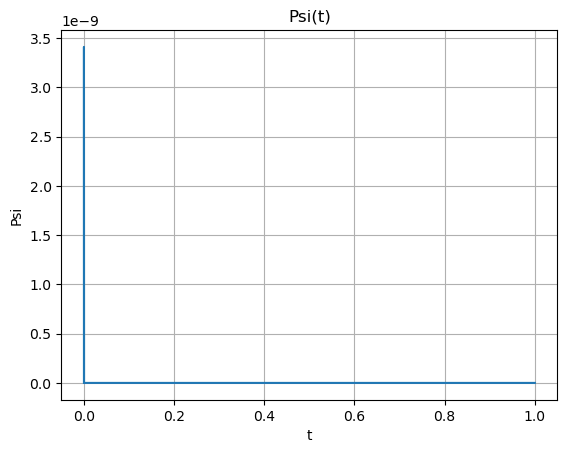

OverflowError: Exceeded cell block limit in Agg.  Please set the value of rcParams['agg.path.chunksize'], (currently 0) to be greater than 100 or increase the path simplification threshold(rcParams['path.simplify_threshold'] = 0.111111111111 by default and path.simplify_threshold = 0.111111111111 on the input).

<Figure size 640x480 with 1 Axes>

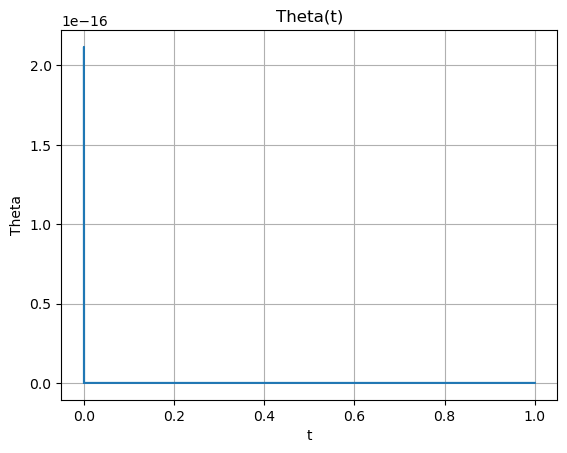

OverflowError: Exceeded cell block limit in Agg.  Please set the value of rcParams['agg.path.chunksize'], (currently 0) to be greater than 100 or increase the path simplification threshold(rcParams['path.simplify_threshold'] = 0.111111111111 by default and path.simplify_threshold = 0.111111111111 on the input).

<Figure size 640x480 with 1 Axes>

In [289]:
import matplotlib.pyplot as plt
names = ["X","Vx","Y","Vy","Phi","Vphi","Psi","Vpsi","Theta","Vtheta"]
for i,name in enumerate(names):
    plt.figure()
    plt.plot(time, solode[:,i])
    plt.xlabel("t"); plt.ylabel(name)
    plt.title(name+"(t)")
    plt.grid(True)
    plt.show()

The following animation code is from ChatGPT and therefore very rough, I just wanted to get an idea of the behaviour. As soon as I can type with both hands again, I will code a much nicer animation :)

Animation with 500 frames
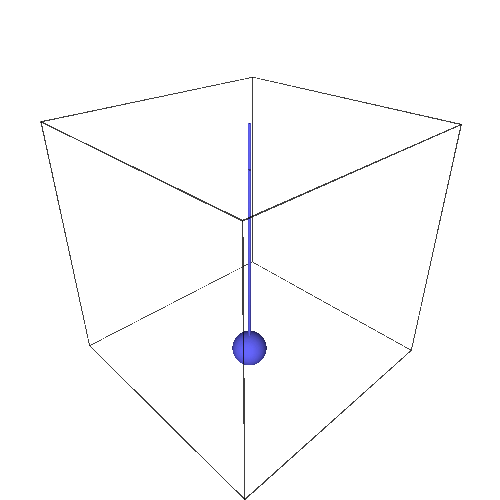

Saved animation as trajectory_orientation.gif
Animation created with 500 frames (step = 1).


In [180]:
# --------------------------
# 3D animation for your solode
# --------------------------
# state indices (as you defined):
# 0: X, 1: Vx, 2: Y, 3: Vy, 4: Phi, 5: Vphi, 6: Psi, 7: Vpsi, 8: Theta, 9: Vtheta

# ensure solode/time are plain lists
time = list(time)
solode = [ list(row) for row in solode ]

n_total = len(solode)
if n_total == 0:
    raise ValueError("solode is empty")

# parameters
R_val = float(parameters.get(R, 1.0))   # fallback to 1.0 if not present
# orientation indicator length: scale with R so it's visible but not huge
orient_length = 0.5 * R_val

# control number of frames (subsample if many steps)
max_frames = 300
step = max(1, n_total // max_frames)

frames = []
# create a lightweight style for trail (fainter)
for k in range(0, n_total, step):
    row = solode[k]
    tnow = float(time[k])

    Xv = float(row[0])
    Yv = float(row[2])

    # angles used to compute unit orientation vector
    Theta_v = float(row[8])
    Psi_v   = float(row[6])

    # orientation vector: visual choice
    ux = float(sin(Theta_v)*cos(Psi_v))
    uy = float(sin(Theta_v)*sin(Psi_v))
    uz = float(cos(Theta_v))

    # orientation line endpoints
    p0 = (Xv, Yv, 0.0)
    p1 = (Xv + orient_length*ux, Yv + orient_length*uy, orient_length*uz)

    # center point and orientation line
    center = point3d(p0, size=30)                         # a visible dot
    orient_line = line3d([p0, p1], thickness=2)

    # trajectory trace up to now (subsample trace points to speed up drawing)
    # keep at most 500 trace points
    max_trace_pts = 500
    trace_step = max(1, (k+1) // max_trace_pts)
    trace_pts = [ (float(solode[j][0]), float(solode[j][2]), 0.0) for j in range(0, k+1, trace_step) ]
    trace = line3d(trace_pts, thickness=1) if len(trace_pts) > 1 else point3d(trace_pts[0])

    # optional: draw velocity arrow (projected into XY plane) -- uncomment if useful
    # Vx = float(row[1]); Vy = float(row[3])
    # vel_scale = 0.2 * R_val
    # vel_arrow = arrow3d((Xv, Yv, 0), (Xv + vel_scale*Vx, Yv + vel_scale*Vy, 0))

    frame = center + orient_line + trace
    frames.append(frame)

# Build and show the animation
anim3d = animate(frames)
anim3d.show()   # display in the notebook (frontend permitting)

# Try saving as GIF (requires ImageMagick / imagemagick convert available)
try:
    anim3d.save('trajectory_orientation.gif')
    print("Saved animation as trajectory_orientation.gif")
except Exception as e:
    print("Could not save GIF (ImageMagick may be missing or saving not supported). Exception:", e)

print("Animation created with {} frames (step = {}).".format(len(frames), step))
